In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import networkx as nx
import community.community_louvain as community_louvain
from pyvis.network import Network
from scipy.stats import kruskal, spearmanr

In [2]:
edge_weights = pd.read_pickle('edge_weights.pkl')
df_final = pd.read_pickle("df_final.pkl")

# Сетевой анализ

## Анализ при пороге = 2

In [3]:
# Thresholding: убираем слабые связи
THRESHOLD = 2
edge_filtered = edge_weights[edge_weights['weight'] >= THRESHOLD]

print(f"   Пар фильмов до фильтрации: {len(edge_weights)}")
print(f"   Пар после порога (>={THRESHOLD} общих жанров): {len(edge_filtered)}")

   Пар фильмов до фильтрации: 1785
   Пар после порога (>=2 общих жанров): 382


In [4]:
# Построение графа
G_movies_2 = nx.Graph()
G_movies_2.add_weighted_edges_from(
    edge_filtered[['film_1', 'film_2', 'weight']].itertuples(index=False)
)

# Добавление атрибутов узлов для последующего анализа
attrs = df_final.set_index('item_id')[['title', 'view_count', 'median_watched_pct', 'genres_list']].to_dict('index')
nx.set_node_attributes(G_movies_2, attrs)

# Глобальные метрики
n_nodes = G_movies_2.number_of_nodes()
n_edges = G_movies_2.number_of_edges()
density = nx.density(G_movies_2)
clustering_coeff = nx.transitivity(G_movies_2)

# Для средней длины пути берем гигантскую компоненту
largest_cc = max(nx.connected_components(G_movies_2), key=len)
avg_path_len = nx.average_shortest_path_length(G_movies_2.subgraph(largest_cc))

print(f"Разведочный анализ сети:")
print(f"-   Узлов (фильмов): {n_nodes}")
print(f"-   Ребер: {n_edges}")
print(f"-   Плотность: {density:.4f}")
print(f"-   Коэффициент кластеризации: {clustering_coeff:.4f}")
print(f"-   Средняя длина пути (в GCC): {avg_path_len:.3f}")


Разведочный анализ сети:
-   Узлов (фильмов): 71
-   Ребер: 378
-   Плотность: 0.1521
-   Коэффициент кластеризации: 0.6196
-   Средняя длина пути (в GCC): 2.745


In [47]:
# Обнаружение сообществ
partition = community_louvain.best_partition(G_movies_2, weight='weight', random_state=42)
nx.set_node_attributes(G_movies_2, partition, 'community')

modularity = community_louvain.modularity(partition, G_movies_2, weight='weight')
print(f" Найдено сообществ: {len(set(partition.values()))} | Модулярность Q: {modularity:.4f}")

 Найдено сообществ: 6 | Модулярность Q: 0.4083


Визуализация

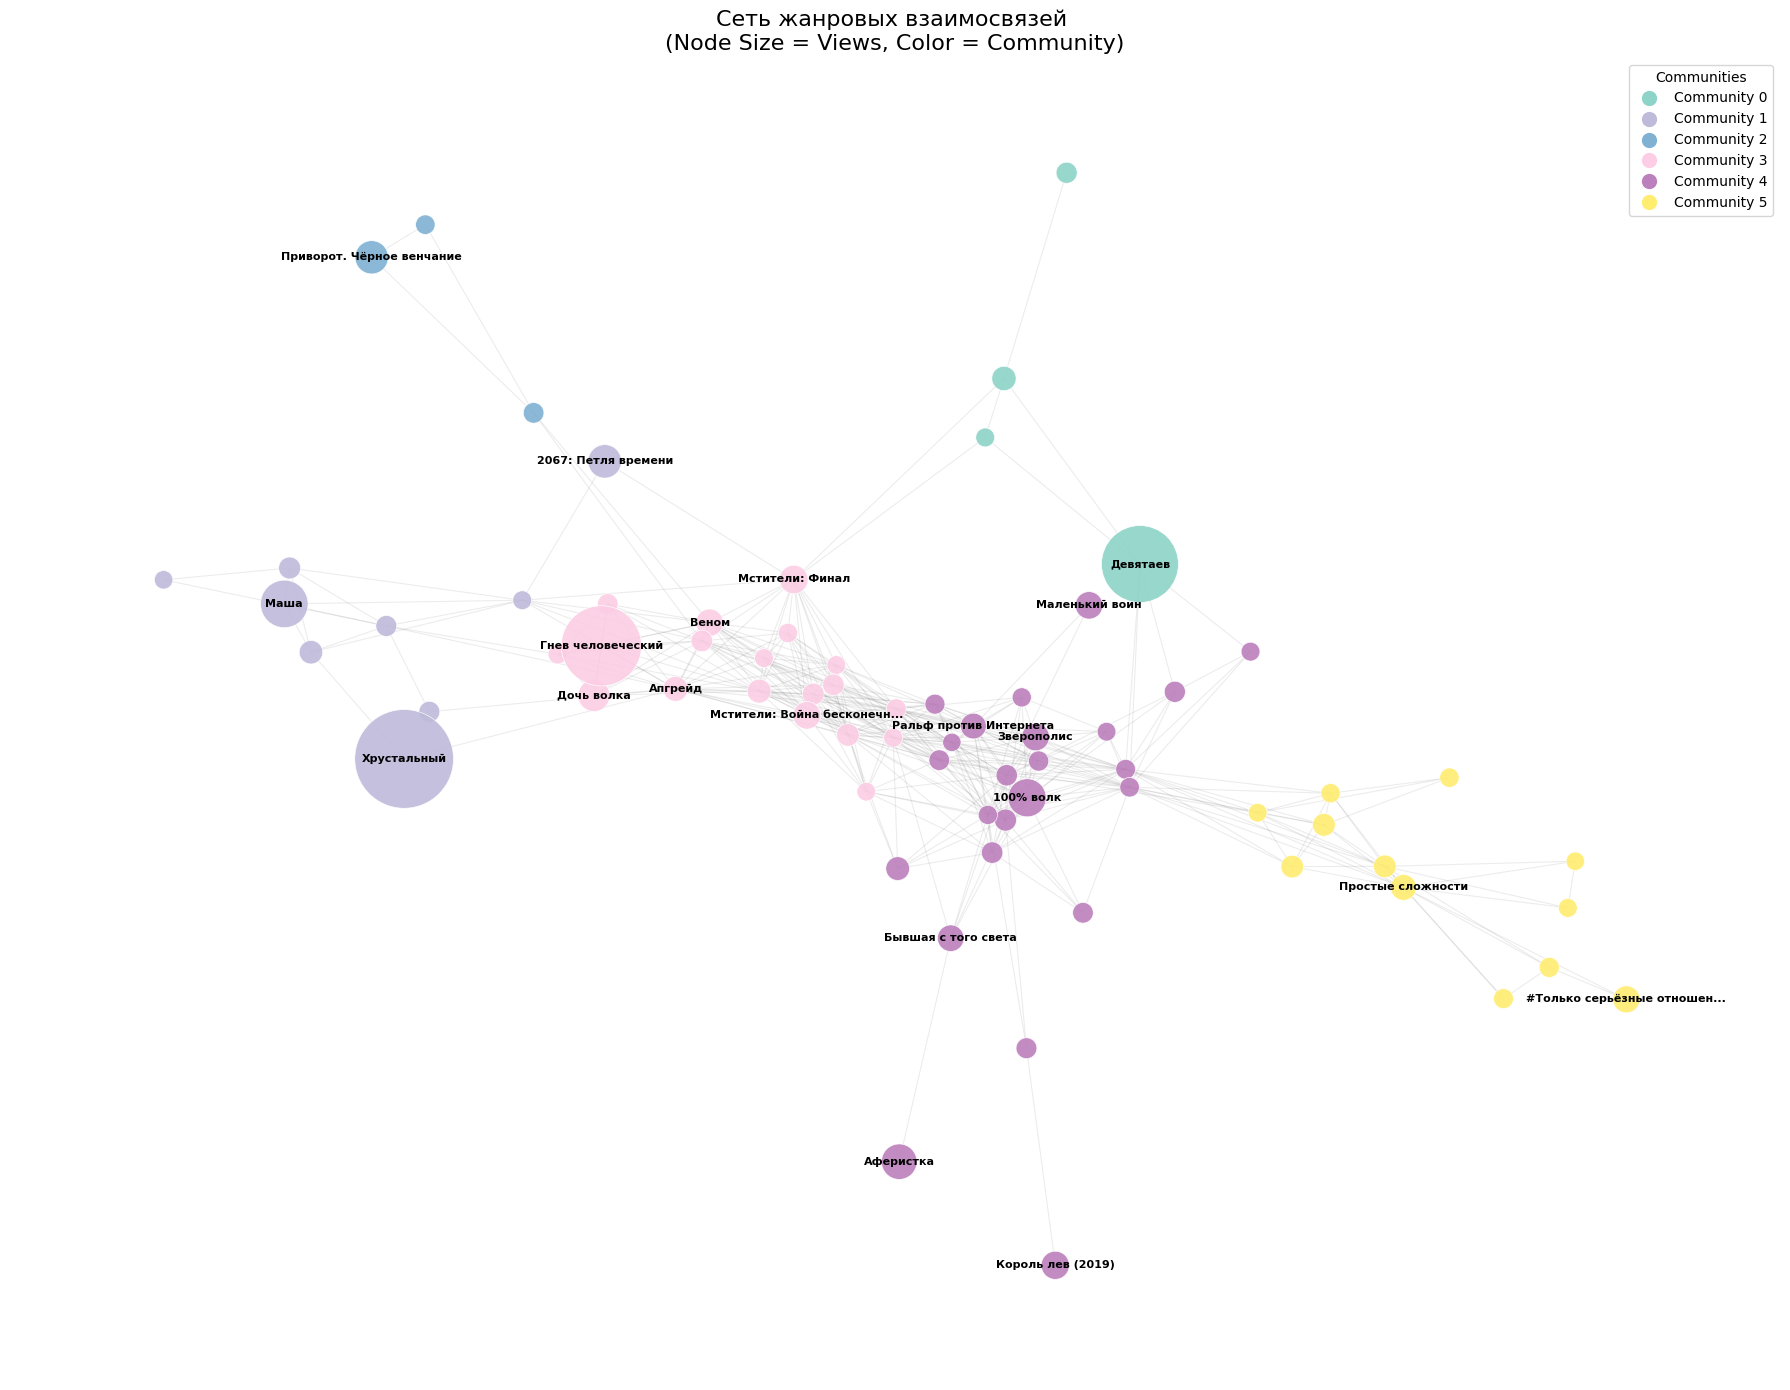

In [48]:
plt.figure(figsize=(18, 14))

# Раскладка с учетом весов ребер
pos = nx.spring_layout(
    G_movies_2, 
    k=2/np.sqrt(G_movies_2.number_of_nodes()), 
    iterations=100, 
    seed=42, 
    weight='weight'
)

communities = sorted(set(partition.values()))
palette = plt.cm.Set3(np.linspace(0, 1, max(len(communities), 1)))

color_map = dict(zip(communities, palette))

default_color = (0.7, 0.7, 0.7) 
node_colors = [color_map.get(partition[n], default_color) for n in G_movies_2.nodes()]


# Размер узлов пропорционален view_count
views = nx.get_node_attributes(G_movies_2, 'view_count')
max_view = max(views.values()) if views else 1
node_sizes = [(v / max_view) * 5000 + 50 for v in views.values()]

# Отрисовка
nx.draw_networkx_edges(G_movies_2, pos, alpha=0.15, width=0.8, edge_color='gray')
nx.draw_networkx_nodes(
    G_movies_2, pos, 
    node_color=node_colors, 
    node_size=node_sizes,
    edgecolors='white', 
    linewidths=0.5, 
    alpha=0.9
)

# Подписываем только топ-20 фильмов по просмотрам
top_films = sorted(views.items(), key=lambda x: x[1], reverse=True)[:20]
labels = {
    n: data['title'][:25] + "..." if len(data['title']) > 25 else data['title'] 
    for n, data in G_movies_2.nodes(data=True) 
    if n in dict(top_films)
}
nx.draw_networkx_labels(G_movies_2, pos, labels, font_size=8, font_weight='bold')

plt.title("Сеть жанровых взаимосвязей \n(Node Size = Views, Color = Community)", fontsize=16)
plt.axis('off')

# Легенда сообществ
handles = [
    plt.Line2D([0], [0], marker='o', color='w', 
               markerfacecolor=color_map[c], markersize=12, label=f'Community {c}') 
    for c in communities
]
plt.legend(handles=handles, loc='upper right', fontsize=10, title="Communities")

plt.tight_layout()
plt.show()

Интерактивная визуализация

In [50]:
# Создаем интерактивную сеть
net = Network(height="800px", width="100%", bgcolor="#ffffff", font_color="black")

# Добавляем узлы с атрибутами
for node in G_movies_2.nodes():
    title = G_movies_2.nodes[node]['title']
    group = partition[node]
    size = (G_movies_2.nodes[node]['view_count'] / max(views.values())) * 30 + 10
    net.add_node(node, label=title, group=group, size=size, title=title)

# Добавляем ребра
for edge in G_movies_2.edges():
    net.add_edge(edge[0], edge[1])

# Настройки физики для лучшего распределения
net.set_options("""
{
  "physics": {
    "forceAtlas2Based": {
      "gravitationalConstant": -50,
      "centralGravity": 0.01,
      "springLength": 100,
      "springConstant": 0.08
    },
    "solver": "forceAtlas2Based",
    "timestep": 0.35,
    "stabilization": {"enabled": true, "iterations": 200}
  }
}
""")

# Сохраняем в HTML файл
net.show("genre_network_interactive.html", notebook=False)

genre_network_interactive.html


In [51]:
# Degree Centrality
deg = dict(G_movies_2.degree()) 

# Betweenness Centrality
betw = nx.betweenness_centrality(G_movies_2, weight='weight')

# PageRank
pagerank = nx.pagerank(G_movies_2, weight='weight', alpha=0.85)

# Eigenvector Centrality
eigenvector = nx.eigenvector_centrality(G_movies_2, weight='weight', max_iter=1000)

# Closeness Centrality
if not nx.is_connected(G_movies_2):
    largest_cc = max(nx.connected_components(G_movies_2), key=len)
    G_gcc = G_movies_2.subgraph(largest_cc).copy()
    closeness_raw = nx.closeness_centrality(G_gcc)
    # Узлам вне GCC присваиваем 0, так как расстояние до них бесконечно
    closeness = {n: closeness_raw.get(n, 0.0) for n in G_movies_2.nodes()}
else:
    closeness = nx.closeness_centrality(G_movies_2)

# Сборка единого DataFrame
nodes_list = list(G_movies_2.nodes())

metrics_df = pd.DataFrame({
    'title': [G_movies_2.nodes[n]['title'] for n in nodes_list],
    'view_count': [G_movies_2.nodes[n].get('view_count', 0) for n in nodes_list],
    'median_watched_pct': [G_movies_2.nodes[n].get('median_watched_pct', np.nan) for n in nodes_list],
    'degree': [deg.get(n, 0) for n in nodes_list],
    'betweenness': [betw.get(n, 0) for n in nodes_list],
    'pagerank': [pagerank.get(n, 0) for n in nodes_list],
    'eigenvector': [eigenvector.get(n, 0) for n in nodes_list],
    'closeness': [closeness.get(n, 0) for n in nodes_list]
})

print(f"Таблица метрик создана: {len(metrics_df)} фильмов")


metrics_df.head()

Таблица метрик создана: 71 фильмов


,title,view_count,median_watched_pct,degree,betweenness,pagerank,eigenvector,closeness
0,Перебежчик,7301,50.0,1,0.000000,0.004182,0.000326,0.263158
1,Томирис,10370,57.0,4,0.031590,0.010953,0.006960,0.355330
2,Маша,45367,88.0,4,0.000000,0.008586,0.002523,0.278884
3,Защитник,8068,95.0,5,0.002504,0.012640,0.002870,0.280000
4,Комната желаний,5401,67.0,10,0.078846,0.015544,0.036804,0.370370


- Анализируем есть ли связь между успехом фильма и принадлежностью к определенному сообществу

In [52]:
comm_attrs = nx.get_node_attributes(G_movies_2, 'community')
title_to_comm = {G_movies_2.nodes[n]['title']: c for n, c in comm_attrs.items()}
metrics_df['community'] = metrics_df['title'].map(title_to_comm).fillna('Unknown')

# Полная сводная статистика (Mean, Median, Min, Max)
comm_stats = metrics_df.groupby('community').agg(
    count=('title', 'count'),
    
    # Просмотры
    mean_views=('view_count', 'mean'),
    median_views=('view_count', 'median'),
    min_views=('view_count', 'min'),
    max_views=('view_count', 'max'),
    
    # Досматриваемость
    mean_watched=('median_watched_pct', 'mean'),
    median_watched=('median_watched_pct', 'median'),
    min_watched=('median_watched_pct', 'min'),
    max_watched=('median_watched_pct', 'max')
).round(2).reset_index()

# Сортируем по медианной досматриваемости
comm_stats = comm_stats.sort_values('community')
print(comm_stats.to_string(index=False))


 community  count  mean_views  median_views  min_views  max_views  mean_watched  median_watched  min_watched  max_watched
         0      4    36307.00        8835.5       5438     122119         65.25            57.0         50.0         97.0
         1      9    34638.11        8068.0       5145     202457         71.78            67.0         40.0         95.0
         2      3    11340.00        6874.0       5958      21188         76.33            72.0         65.0         92.0
         3     19    15465.37        7740.0       5315     132865         60.29            61.0         30.0         92.0
         4     24     9709.50        7204.5       5029      28372         68.69            67.5         35.0         93.0
         5     12     7636.17        6339.5       5111      13269         56.08            48.0         27.0        100.0


Берем логарифмическую шкалы для количества просмотров уникальных пользователей

C:\Users\user\AppData\Local\Temp\ipykernel_29688\4017404999.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=metrics_df, x='community', y='median_watched_pct',
C:\Users\user\AppData\Local\Temp\ipykernel_29688\4017404999.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=metrics_df, x='community', y='view_count',


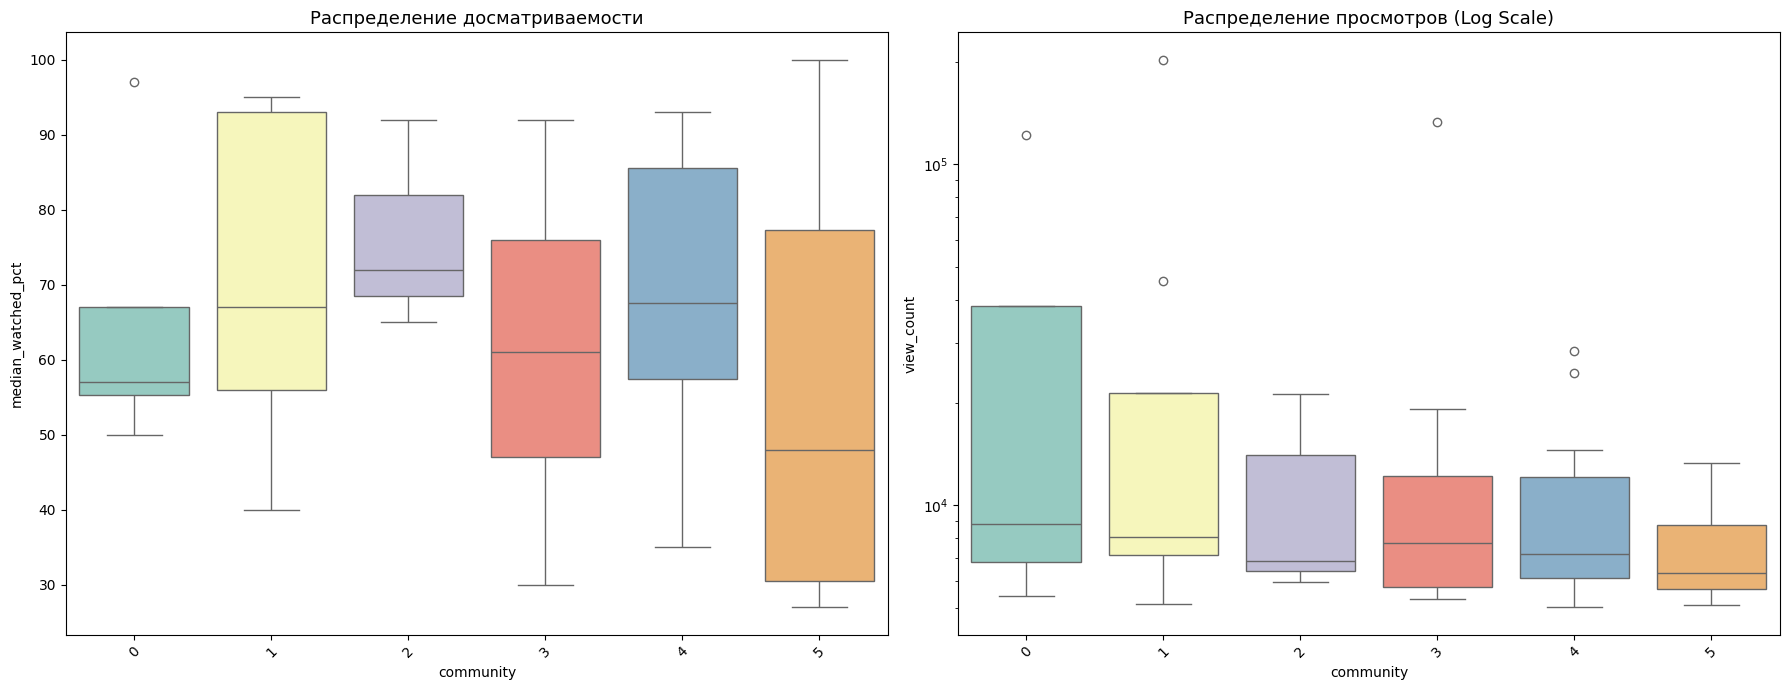

In [53]:
# Визуализация распределений
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
order = comm_stats['community'].tolist()

sns.boxplot(data=metrics_df, x='community', y='median_watched_pct', 
            ax=axes[0], palette='Set3', order=order)
axes[0].set_title("Распределение досматриваемости", fontsize=13)
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=metrics_df, x='community', y='view_count', 
            ax=axes[1], palette='Set3', order=order)
axes[1].set_yscale('log')
axes[1].set_title("Распределение просмотров (Log Scale)", fontsize=13)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [54]:
# Проверка значимости различий
groups_w = [g['median_watched_pct'].values for _, g in metrics_df.groupby('community')]
groups_v = [g['view_count'].values for _, g in metrics_df.groupby('community')]

stat_w, p_w = kruskal(*groups_w)
stat_v, p_v = kruskal(*groups_v)

print(f"\n Kruskal-Wallis Test:")
print(f"   Досматриваемость: H={stat_w:.2f}, p={p_w:.4f}")
print(f"   Просмотры:        H={stat_v:.2f}, p={p_v:.4f}")


 Kruskal-Wallis Test:
   Досматриваемость: H=5.17, p=0.3956
   Просмотры:        H=2.37, p=0.7959


Отбираем ТОП-5 фильмов по различным метрикам

In [55]:
print("\n Топ-5 фильмов по Degree:")
print(metrics_df.nlargest(5, 'degree')[['title', 'degree', 'view_count']].to_string(index=False))

print("\n\n Топ-5 фильмов по PageRank:")
print(metrics_df.nlargest(5, 'pagerank')[['title', 'pagerank', 'view_count']].to_string(index=False))

print("\n\n Топ-5 фильмов по betweenness:")
print(metrics_df.nlargest(5, 'betweenness')[['title', 'betweenness', 'view_count']].to_string(index=False))



 Топ-5 фильмов по Degree:
                 title  degree  view_count
         Тор: Рагнарёк      29        5651
      Стражи Галактики      27        6376
                 Вверх      24        6148
               Рататуй      24        5986
Ральф против Интернета      23       11851


 Топ-5 фильмов по PageRank:
              title  pagerank  view_count
      Тор: Рагнарёк  0.033230        5651
            Рататуй  0.030194        5986
              Вверх  0.029860        6148
   Стражи Галактики  0.028930        6376
Алита: Боевой ангел  0.026696        9872


 Топ-5 фильмов по betweenness:
           title  betweenness  view_count
           Вверх     0.151761        6148
         Рататуй     0.147789        5986
         Апгрейд     0.142830       10915
   Тор: Рагнарёк     0.112509        5651
Стражи Галактики     0.104728        6376


In [56]:
print("\n\n Топ-5 фильмов по closeness:")
print(metrics_df.nlargest(5, 'closeness')[['title', 'closeness', 'view_count']].to_string(index=False))

print("\n\n Топ-5 фильмов по eigenvector:")
print(metrics_df.nlargest(5, 'eigenvector')[['title', 'eigenvector', 'view_count']].to_string(index=False))



 Топ-5 фильмов по closeness:
                     title  closeness  view_count
             Тор: Рагнарёк   0.560000        5651
          Стражи Галактики   0.546875        6376
Kingsman: Секретная служба   0.500000        6882
                     Вверх   0.496454        6148
                   Рататуй   0.496454        5986


 Топ-5 фильмов по eigenvector:
                 title  eigenvector  view_count
         Тор: Рагнарёк     0.304966        5651
      Стражи Галактики     0.280299        6376
Ральф против Интернета     0.241627       11851
              Мстители     0.233343        8765
               Миньоны     0.224438        5029


Проводим корреляционный анализ между метриками центральности и показателями популярности фильмов

In [57]:
# Корреляция Спирмена
centrality_cols = ['degree', 'betweenness', 'pagerank', 'eigenvector', 'closeness']
success_cols = ['view_count', 'median_watched_pct']

results = []
for c_col in centrality_cols:
    for s_col in success_cols:
        corr, p_value = spearmanr(metrics_df[c_col], metrics_df[s_col])
        results.append({
            'Centrality': c_col,
            'Success Metric': s_col,
            'Spearman_rho': round(corr, 4),
            'p_value': f"{p_value:.2e}"
        })

corr_df = pd.DataFrame(results)

corr_df

,Centrality,Success Metric,Spearman_rho,p_value
0,degree,view_count,-0.1252,2.98e-01
1,degree,median_watched_pct,0.1091,3.65e-01
2,betweenness,view_count,-0.0249,8.37e-01
3,betweenness,median_watched_pct,0.0903,4.54e-01
4,pagerank,view_count,-0.0728,5.46e-01
5,pagerank,median_watched_pct,0.1498,2.12e-01
6,eigenvector,view_count,-0.1007,4.03e-01
7,eigenvector,median_watched_pct,0.1183,3.26e-01
8,closeness,view_count,-0.0978,4.17e-01
9,closeness,median_watched_pct,0.0956,4.28e-01


In [58]:
r_watch = nx.attribute_assortativity_coefficient(G_movies_2, 'median_watched_pct')
print(f"Коэффициент ассортативности по досматриваемости: r = {r_watch:.4f}")
        

Коэффициент ассортативности по досматриваемости: r = -0.0159



## Анализ при пороге = 3

In [29]:
# Thresholding: убираем слабые связи
THRESHOLD = 3
edge_filtered = edge_weights[edge_weights['weight'] >= THRESHOLD]

print(f"   Пар фильмов до фильтрации: {len(edge_weights)}")
print(f"   Пар после порога (>={THRESHOLD} общих жанров): {len(edge_filtered)}")

   Пар фильмов до фильтрации: 1785
   Пар после порога (>=3 общих жанров): 84


In [ ]:
# Построение графа
G_movies_3 = nx.Graph()
G_movies_3.add_weighted_edges_from(
    edge_filtered[['film_1', 'film_2', 'weight']].itertuples(index=False)
)

# Добавление атрибутов узлов для последующего анализа
attrs = df_final.set_index('item_id')[['title', 'view_count', 'median_watched_pct', 'genres_list']].to_dict('index')
nx.set_node_attributes(G_movies_3, attrs)

# Глобальные метрики
n_nodes = G_movies_3.number_of_nodes()
n_edges = G_movies_3.number_of_edges()
density = nx.density(G_movies_3)
clustering_coeff = nx.transitivity(G_movies_3)

# Для средней длины пути берем гигантскую компоненту
largest_cc = max(nx.connected_components(G_movies_3), key=len)
avg_path_len = nx.average_shortest_path_length(G_movies_3.subgraph(largest_cc))

print(f"Разведочный анализ сети:")
print(f"-   Узлов (фильмов): {n_nodes}")
print(f"-   Ребер: {n_edges}")
print(f"-   Плотность: {density:.4f}")
print(f"-   Коэффициент кластеризации: {clustering_coeff:.4f}")
print(f"-   Средняя длина пути (в GCC): {avg_path_len:.3f}")


Разведочный анализ сети:
-   Узлов (фильмов): 37
-   Ребер: 84
-   Плотность: 0.1261
-   Коэффициент кластеризации: 0.6398
-   Средняя длина пути (в GCC): 2.393


In [59]:
# Обнаружение сообществ
partition = community_louvain.best_partition(G_movies_3, weight='weight', random_state=42)
nx.set_node_attributes(G_movies_3, partition, 'community')

modularity = community_louvain.modularity(partition, G_movies_3, weight='weight')
print(f" Найдено сообществ: {len(set(partition.values()))} | Модулярность Q: {modularity:.4f}")

 Найдено сообществ: 8 | Модулярность Q: 0.5361


Визуализация

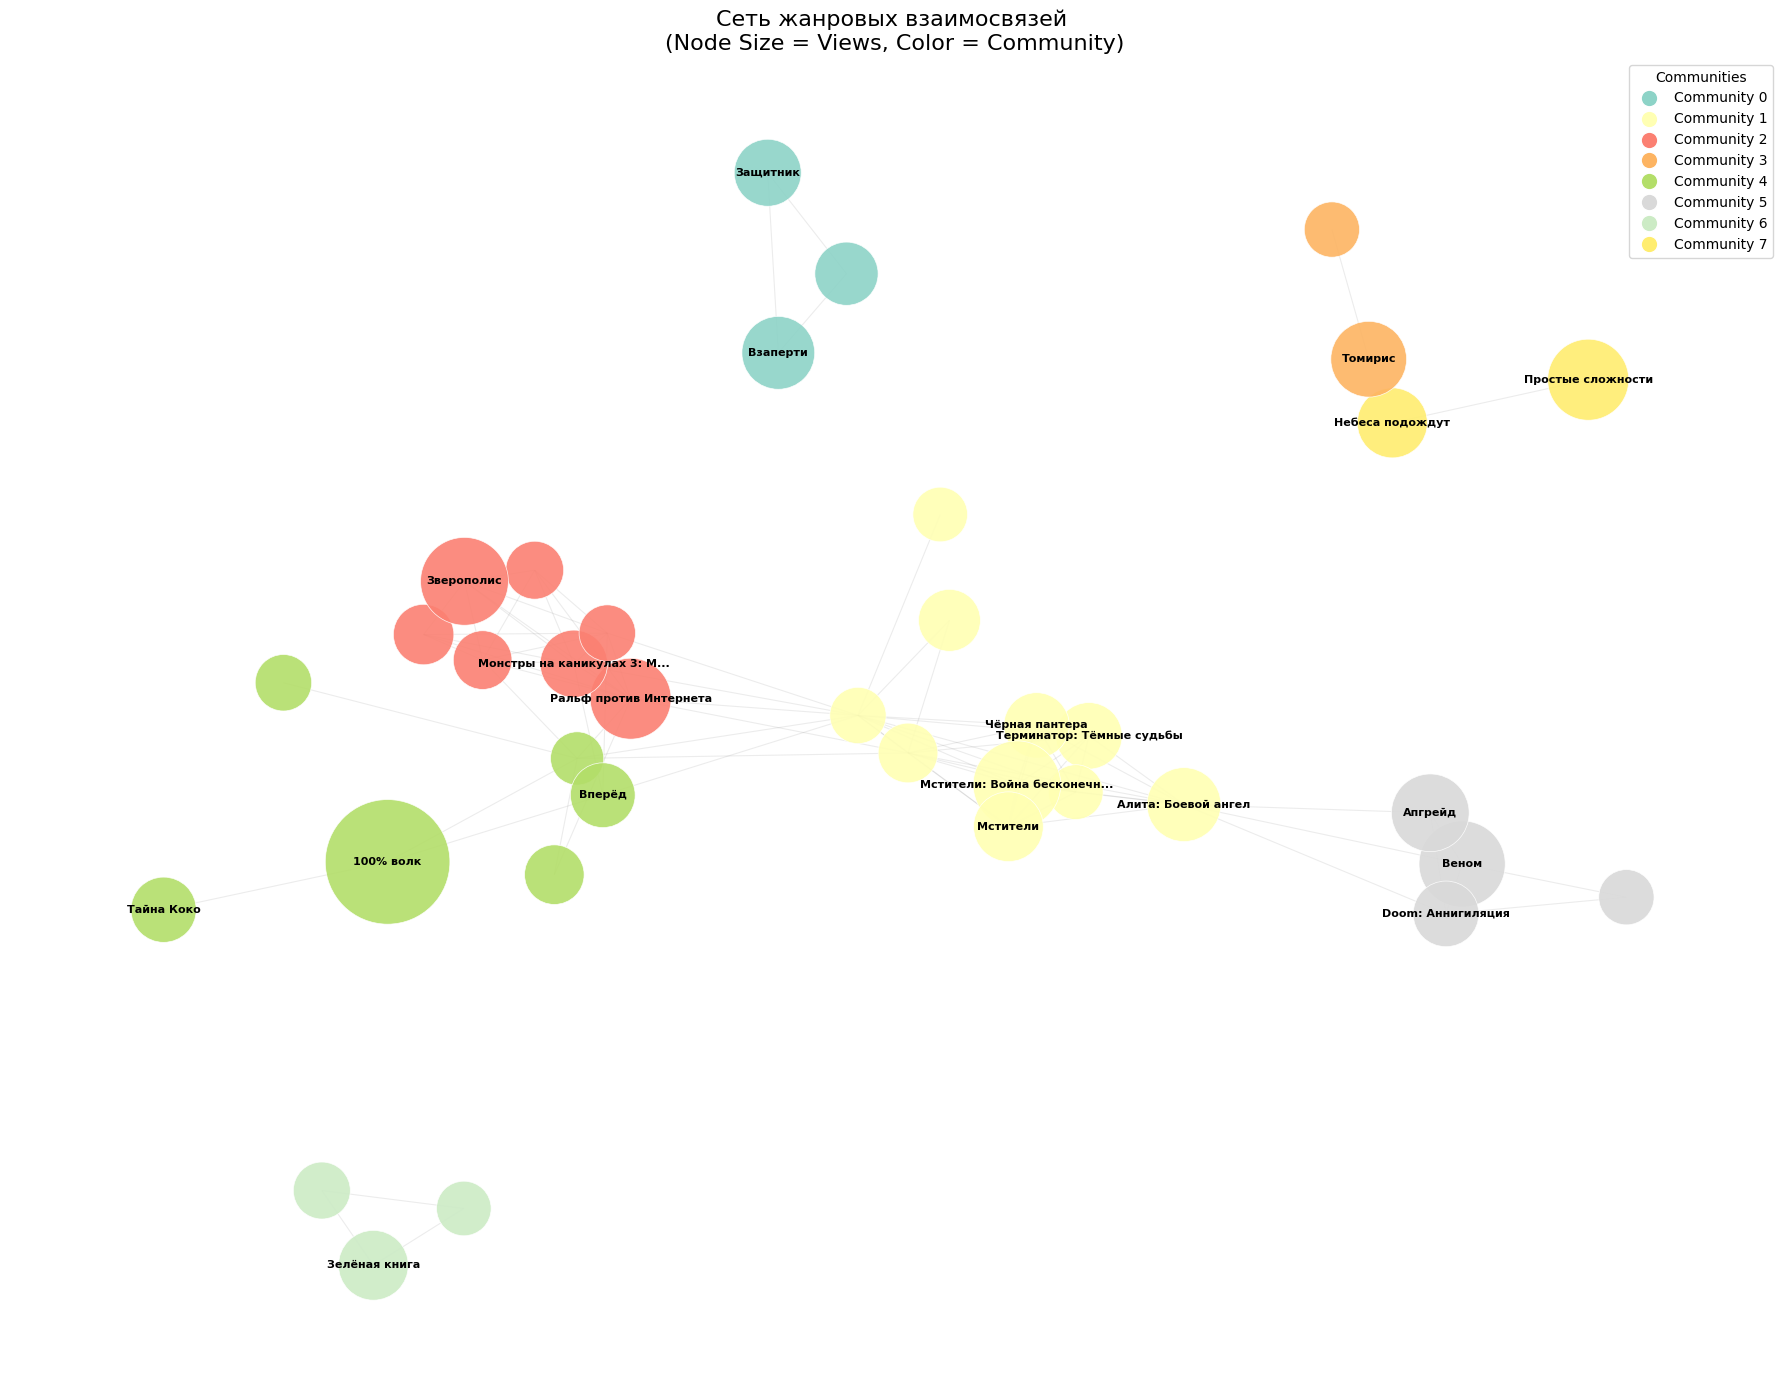

In [60]:
plt.figure(figsize=(18, 14))

# Раскладка с учетом весов ребер
pos = nx.spring_layout(
    G_movies_3, 
    k=2/np.sqrt(G_movies_3.number_of_nodes()), 
    iterations=26, 
    seed=42, 
    weight='weight'
)

communities = sorted(set(partition.values()))
palette = plt.cm.Set3(np.linspace(0, 1, max(len(communities), 1)))

# Создаем словарь: ID сообщества -> Цвет
color_map = dict(zip(communities, palette))

default_color = (0.7, 0.7, 0.7) 
node_colors = [color_map.get(partition[n], default_color) for n in G_movies_3.nodes()]


# Размер узлов пропорционален view_count
views = nx.get_node_attributes(G_movies_3, 'view_count')
max_view = max(views.values()) if views else 1
node_sizes = [(v / max_view) * 8000 + 50 for v in views.values()]

# Отрисовка
nx.draw_networkx_edges(G_movies_3, pos, alpha=0.15, width=0.8, edge_color='gray')
nx.draw_networkx_nodes(
    G_movies_3, pos, 
    node_color=node_colors, 
    node_size=node_sizes,
    edgecolors='white', 
    linewidths=0.5, 
    alpha=0.9
)

# Подписываем только топ-20 фильмов по просмотрам
top_films = sorted(views.items(), key=lambda x: x[1], reverse=True)[:20]
labels = {
    n: data['title'][:25] + "..." if len(data['title']) > 25 else data['title'] 
    for n, data in G_movies_3.nodes(data=True) 
    if n in dict(top_films)
}
nx.draw_networkx_labels(G_movies_3, pos, labels, font_size=8, font_weight='bold')

plt.title("Сеть жанровых взаимосвязей \n(Node Size = Views, Color = Community)", fontsize=16)
plt.axis('off')

# Легенда сообществ
handles = [
    plt.Line2D([0], [0], marker='o', color='w', 
               markerfacecolor=color_map[c], markersize=12, label=f'Community {c}') 
    for c in communities
]
plt.legend(handles=handles, loc='upper right', fontsize=10, title="Communities")

plt.tight_layout()
plt.show()

Интерактивная визуализация

In [61]:
# Создаем интерактивную сеть
net = Network(height="800px", width="100%", bgcolor="#ffffff", font_color="black")

# Добавляем узлы с атрибутами
for node in G_movies_3.nodes():
    title = G_movies_3.nodes[node]['title']
    group = partition[node]
    size = (G_movies_3.nodes[node]['view_count'] / max(views.values())) * 30 + 10
    net.add_node(node, label=title, group=group, size=size, title=title) # title - это всплывающая подсказка

# Добавляем ребра
for edge in G_movies_3.edges():
    net.add_edge(edge[0], edge[1])

# Настройки физики для лучшего распределения
net.set_options("""
{
  "physics": {
    "forceAtlas2Based": {
      "gravitationalConstant": -50,
      "centralGravity": 0.01,
      "springLength": 100,
      "springConstant": 0.08
    },
    "solver": "forceAtlas2Based",
    "timestep": 0.35,
    "stabilization": {"enabled": true, "iterations": 200}
  }
}
""")

# Сохраняем в HTML файл
net.show("genre_network_interactive.html", notebook=False) 

genre_network_interactive.html


In [33]:
# 1. Degree Centrality
deg = dict(G_movies_3.degree()) 

# 2. Betweenness Centrality
betw = nx.betweenness_centrality(G_movies_3, weight='weight')

# 3. PageRank
pagerank = nx.pagerank(G_movies_3, weight='weight', alpha=0.85)

# 4. Eigenvector Centrality
eigenvector = nx.eigenvector_centrality(G_movies_3, weight='weight', max_iter=1000)

# 5. Closeness Centrality
if not nx.is_connected(G_movies_3):
    largest_cc = max(nx.connected_components(G_movies_3), key=len)
    G_gcc = G_movies_3.subgraph(largest_cc).copy()
    closeness_raw = nx.closeness_centrality(G_gcc)
    # Узлам вне GCC присваиваем 0, так как расстояние до них бесконечно
    closeness = {n: closeness_raw.get(n, 0.0) for n in G_movies_3.nodes()}
else:
    closeness = nx.closeness_centrality(G_movies_3)

# 6. Сборка единого DataFrame
nodes_list = list(G_movies_3.nodes())

metrics_df = pd.DataFrame({
    'title': [G_movies_3.nodes[n]['title'] for n in nodes_list],
    'view_count': [G_movies_3.nodes[n].get('view_count', 0) for n in nodes_list],
    'median_watched_pct': [G_movies_3.nodes[n].get('median_watched_pct', np.nan) for n in nodes_list],
    'degree': [deg.get(n, 0) for n in nodes_list],
    'betweenness': [betw.get(n, 0) for n in nodes_list],
    'pagerank': [pagerank.get(n, 0) for n in nodes_list],
    'eigenvector': [eigenvector.get(n, 0) for n in nodes_list],
    'closeness': [closeness.get(n, 0) for n in nodes_list]
})

print(f"Таблица метрик создана: {len(metrics_df)} фильмов")


metrics_df.head()

Таблица метрик создана: 37 фильмов


,title,view_count,median_watched_pct,degree,betweenness,pagerank,eigenvector,closeness
0,Защитник,8068,95.0,2,0.0,0.027027,9.891466e-22,0.000000
1,Экстрасенс 2: Лабиринты разума,7171,56.0,2,0.0,0.027027,9.891466e-22,0.000000
2,Взаперти,9566,95.0,2,0.0,0.027027,9.891466e-22,0.000000
3,Терминатор: Тёмные судьбы,7958,92.0,7,0.0,0.028875,2.607053e-01,0.472727
4,Человек-паук: Вдали от дома,5350,30.0,7,0.0,0.028875,2.607053e-01,0.472727


- Анализируем есть ли связь между успехом фильма и принадлежностью к определенному сообществу

In [66]:
comm_attrs = nx.get_node_attributes(G_movies_2, 'community')
title_to_comm = {G_movies_2.nodes[n]['title']: c for n, c in comm_attrs.items()}
metrics_df['community'] = metrics_df['title'].map(title_to_comm).fillna('Unknown')

# Полная сводная статистика (Mean, Median, Min, Max)
comm_stats = metrics_df.groupby('community').agg(
    count=('title', 'count'),
    
    # Просмотры
    mean_views=('view_count', 'mean'),
    median_views=('view_count', 'median'),
    min_views=('view_count', 'min'),
    max_views=('view_count', 'max'),
    
    # Досматриваемость
    mean_watched=('median_watched_pct', 'mean'),
    median_watched=('median_watched_pct', 'median'),
    min_watched=('median_watched_pct', 'min'),
    max_watched=('median_watched_pct', 'max')
).round(2).reset_index()

# Сортируем по медианной досматриваемости
comm_stats = comm_stats.sort_values('community')

print(comm_stats.to_string(index=False))


 community  count  mean_views  median_views  min_views  max_views  mean_watched  median_watched  min_watched  max_watched
         0      4    36307.00        8835.5       5438     122119         65.25            57.0         50.0         97.0
         1      9    34638.11        8068.0       5145     202457         71.78            67.0         40.0         95.0
         2      3    11340.00        6874.0       5958      21188         76.33            72.0         65.0         92.0
         3     19    15465.37        7740.0       5315     132865         60.29            61.0         30.0         92.0
         4     24     9709.50        7204.5       5029      28372         68.69            67.5         35.0         93.0
         5     12     7636.17        6339.5       5111      13269         56.08            48.0         27.0        100.0


Берем логарифмическую шкалы для количества просмотров уникальных пользователей

C:\Users\user\AppData\Local\Temp\ipykernel_29688\4017404999.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=metrics_df, x='community', y='median_watched_pct',
C:\Users\user\AppData\Local\Temp\ipykernel_29688\4017404999.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=metrics_df, x='community', y='view_count',


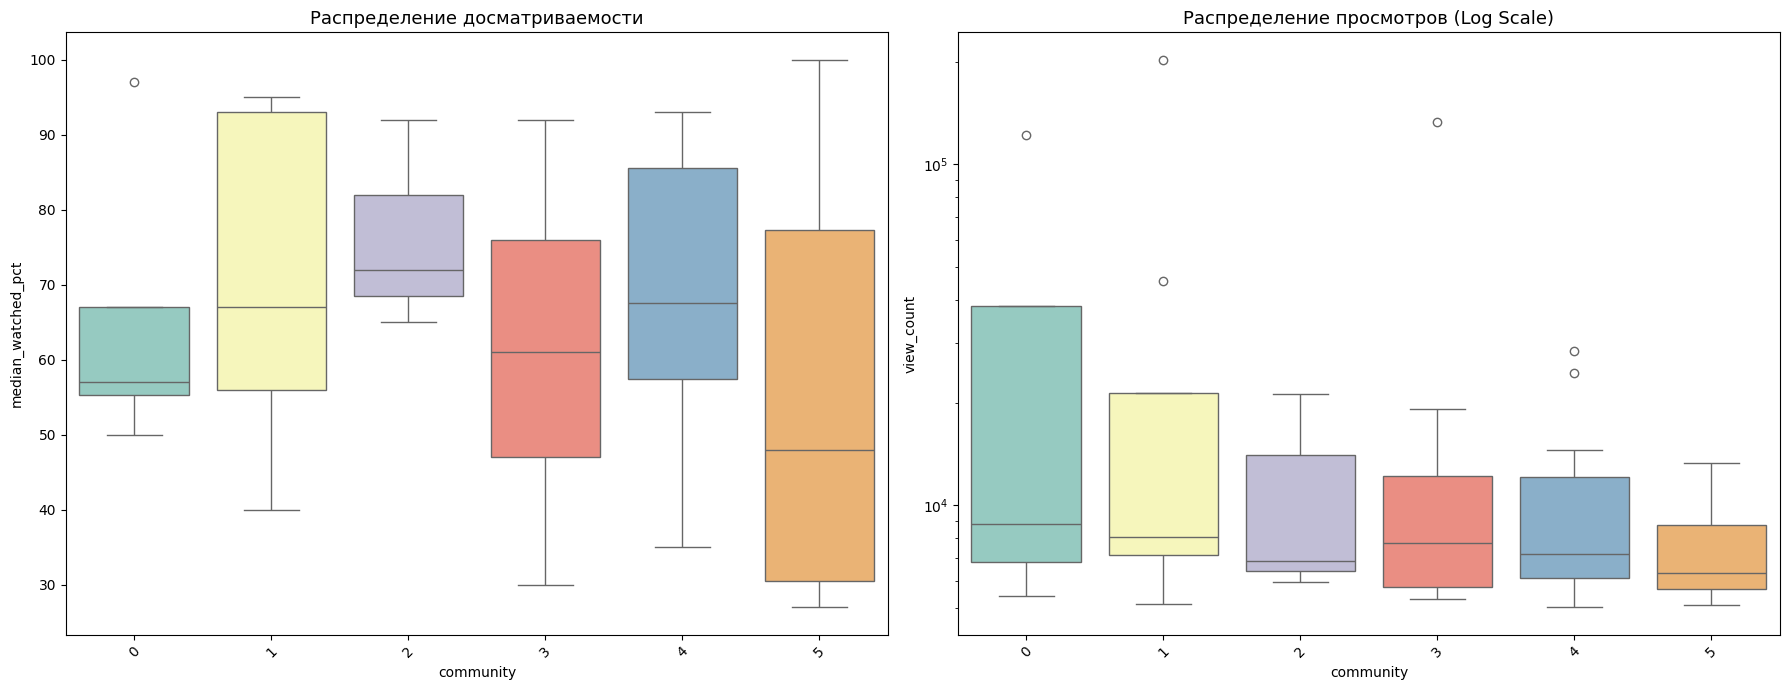

In [67]:
# Визуализация распределений
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
order = comm_stats['community'].tolist()

sns.boxplot(data=metrics_df, x='community', y='median_watched_pct', 
            ax=axes[0], palette='Set3', order=order)
axes[0].set_title("Распределение досматриваемости", fontsize=13)
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=metrics_df, x='community', y='view_count', 
            ax=axes[1], palette='Set3', order=order)
axes[1].set_yscale('log')
axes[1].set_title("Распределение просмотров (Log Scale)", fontsize=13)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [68]:
# Проверка значимости различий
groups_w = [g['median_watched_pct'].values for _, g in metrics_df.groupby('community')]
groups_v = [g['view_count'].values for _, g in metrics_df.groupby('community')]

stat_w, p_w = kruskal(*groups_w)
stat_v, p_v = kruskal(*groups_v)

print(f"\n Kruskal-Wallis Test:")
print(f"   Досматриваемость: H={stat_w:.2f}, p={p_w:.4f}")
print(f"   Просмотры:        H={stat_v:.2f}, p={p_v:.4f}")


 Kruskal-Wallis Test:
   Досматриваемость: H=5.17, p=0.3956
   Просмотры:        H=2.37, p=0.7959


Отбираем ТОП-5 фильмов по различным метрикам

In [69]:
print("\n Топ-5 фильмов по Degree:")
print(metrics_df.nlargest(5, 'degree')[['title', 'degree', 'view_count']].to_string(index=False))

print("\n\n Топ-5 фильмов по PageRank:")
print(metrics_df.nlargest(5, 'pagerank')[['title', 'pagerank', 'view_count']].to_string(index=False))

print("\n\n Топ-5 фильмов по betweenness:")
print(metrics_df.nlargest(5, 'betweenness')[['title', 'betweenness', 'view_count']].to_string(index=False))



 Топ-5 фильмов по Degree:
                 title  degree  view_count
         Тор: Рагнарёк      29        5651
      Стражи Галактики      27        6376
                 Вверх      24        6148
               Рататуй      24        5986
Ральф против Интернета      23       11851


 Топ-5 фильмов по PageRank:
              title  pagerank  view_count
      Тор: Рагнарёк  0.033230        5651
            Рататуй  0.030194        5986
              Вверх  0.029860        6148
   Стражи Галактики  0.028930        6376
Алита: Боевой ангел  0.026696        9872


 Топ-5 фильмов по betweenness:
           title  betweenness  view_count
           Вверх     0.151761        6148
         Рататуй     0.147789        5986
         Апгрейд     0.142830       10915
   Тор: Рагнарёк     0.112509        5651
Стражи Галактики     0.104728        6376


In [70]:
print("\n\n Топ-5 фильмов по closeness:")
print(metrics_df.nlargest(5, 'closeness')[['title', 'closeness', 'view_count']].to_string(index=False))

print("\n\n Топ-5 фильмов по eigenvector:")
print(metrics_df.nlargest(5, 'eigenvector')[['title', 'eigenvector', 'view_count']].to_string(index=False))



 Топ-5 фильмов по closeness:
                     title  closeness  view_count
             Тор: Рагнарёк   0.560000        5651
          Стражи Галактики   0.546875        6376
Kingsman: Секретная служба   0.500000        6882
                     Вверх   0.496454        6148
                   Рататуй   0.496454        5986


 Топ-5 фильмов по eigenvector:
                 title  eigenvector  view_count
         Тор: Рагнарёк     0.304966        5651
      Стражи Галактики     0.280299        6376
Ральф против Интернета     0.241627       11851
              Мстители     0.233343        8765
               Миньоны     0.224438        5029


Проводим корреляционный анализ между метриками центральности и показателями популярности фильмов

In [71]:
# Корреляция Спирмена
centrality_cols = ['degree', 'betweenness', 'pagerank', 'eigenvector', 'closeness']
success_cols = ['view_count', 'median_watched_pct']

results = []
for c_col in centrality_cols:
    for s_col in success_cols:
        corr, p_value = spearmanr(metrics_df[c_col], metrics_df[s_col])
        results.append({
            'Centrality': c_col,
            'Success Metric': s_col,
            'Spearman_rho': round(corr, 4),
            'p_value': f"{p_value:.2e}"
        })

corr_df = pd.DataFrame(results)

corr_df

,Centrality,Success Metric,Spearman_rho,p_value
0,degree,view_count,-0.1252,2.98e-01
1,degree,median_watched_pct,0.1091,3.65e-01
2,betweenness,view_count,-0.0249,8.37e-01
3,betweenness,median_watched_pct,0.0903,4.54e-01
4,pagerank,view_count,-0.0728,5.46e-01
5,pagerank,median_watched_pct,0.1498,2.12e-01
6,eigenvector,view_count,-0.1007,4.03e-01
7,eigenvector,median_watched_pct,0.1183,3.26e-01
8,closeness,view_count,-0.0978,4.17e-01
9,closeness,median_watched_pct,0.0956,4.28e-01


In [72]:
r_watch = nx.attribute_assortativity_coefficient(G_movies_3, 'median_watched_pct')
print(f"Коэффициент ассортативности по досматриваемости: r = {r_watch:.4f}")
        

Коэффициент ассортативности по досматриваемости: r = -0.0218
